# POI QA Pipeline Notebook

This notebook is self-contained and runs the POI QA checks directly in notebook cells.

## Workflow
1. Import required libraries
2. Define QA helpers and checks
3. Run the QA pipeline on the sample CSV
4. Review tables and generated outputs


## 1) Import Required Libraries
Import libraries for data processing and notebook/output handling (`nbformat`/IPython included).

In [7]:
from pathlib import Path
import math
import re
from difflib import SequenceMatcher

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display, Markdown

try:
    import nbformat  # optional: notebook structure utility
except ImportError:
    nbformat = None
    print("nbformat is not installed; continuing without it.")

pd.set_option("display.max_colwidth", 120)
pd.set_option("display.width", 160)
sns.set_theme(style="whitegrid", context="talk")

workspace = Path.cwd()
print(f"Workspace: {workspace}")

import warnings
warnings.filterwarnings("ignore")

Workspace: c:\Users\Mehedi\Downloads\files


## 2) Define QA Helpers
Define the core QA rules and the reusable pipeline used by the notebook and the Streamlit app.

In [8]:
# Config
DUPLICATE_DISTANCE_METERS = 60
DUPLICATE_NAME_SIMILARITY = 0.55
REQUIRED_FIELDS = ["address", "phone", "category"]

CATEGORY_KEYWORDS = {
    "hospital": "hospital",
    "clinic": "hospital",
    "diagnostic": "hospital",
    "pharmacy": "pharmacy",
    "medical store": "pharmacy",
    "medicine": "pharmacy",
    "bank": "bank",
    "atm": "bank",
    "restaurant": "restaurant",
    "kabab": "restaurant",
    "dine": "restaurant",
    "cafe": "restaurant",
    "mosque": "mosque",
    "masjid": "mosque",
    "school": "school",
    "college": "school",
}

ADDRESS_STANDARDIZATION = [
    (r"\bRd\.?\b", "Road"),
    (r"\bR/A\b", "Residential Area"),
    (r"\bNo\.?\b", "No"),
    (r"\bHouse-\s*", "House "),
    (r"\s+", " "),
]

GENERIC_NAME_WORDS = {
    "ltd", "limited", "branch", "store", "shop", "dhanmondi", "bank", "school",
    "pharmacy", "hospital", "restaurant", "mosque", "centre", "center", "college",
}


def haversine_meters(lat1, lon1, lat2, lon2):
    r = 6371000
    p1, p2 = math.radians(lat1), math.radians(lat2)
    dphi = math.radians(lat2 - lat1)
    dlambda = math.radians(lon2 - lon1)
    a = math.sin(dphi / 2) ** 2 + math.cos(p1) * math.cos(p2) * math.sin(dlambda / 2) ** 2
    return 2 * r * math.asin(math.sqrt(a))


def normalize_name(name):
    name = str(name).lower()
    name = re.sub(r"[.,&\-]", " ", name)
    tokens = [t for t in name.split() if t not in GENERIC_NAME_WORDS]
    return " ".join(tokens).strip()


def name_similarity(a, b):
    return SequenceMatcher(None, normalize_name(a), normalize_name(b)).ratio()


def standardize_address(addr):
    if pd.isna(addr) or str(addr).strip() == "":
        return addr
    out = str(addr)
    for pattern, replacement in ADDRESS_STANDARDIZATION:
        out = re.sub(pattern, replacement, out)
    return out.strip()


def expected_category(name):
    lname = str(name).lower()
    for keyword, category in CATEGORY_KEYWORDS.items():
        if keyword in lname:
            return category
    return None


def find_duplicates(df):
    flags = []
    seen_pairs = set()
    records = df.to_dict("records")

    for i in range(len(records)):
        for j in range(i + 1, len(records)):
            a, b = records[i], records[j]
            dist = haversine_meters(a["latitude"], a["longitude"], b["latitude"], b["longitude"])
            if dist > DUPLICATE_DISTANCE_METERS:
                continue
            sim = name_similarity(a["name"], b["name"])
            if sim >= DUPLICATE_NAME_SIMILARITY:
                pair_key = tuple(sorted([a["poi_id"], b["poi_id"]]))
                if pair_key in seen_pairs:
                    continue
                seen_pairs.add(pair_key)
                flags.append({
                    "poi_id_1": a["poi_id"], "name_1": a["name"],
                    "poi_id_2": b["poi_id"], "name_2": b["name"],
                    "distance_meters": round(dist, 1),
                    "name_similarity": round(sim, 2),
                    "suggested_action": "merge / keep most complete record",
                })
    return pd.DataFrame(flags)


def find_missing_fields(df):
    flags = []
    for _, row in df.iterrows():
        missing = [f for f in REQUIRED_FIELDS if pd.isna(row.get(f)) or str(row.get(f)).strip() == ""]
        if missing:
            flags.append({
                "poi_id": row["poi_id"],
                "name": row["name"],
                "missing_fields": ", ".join(missing),
            })
    return pd.DataFrame(flags)


def find_naming_inconsistencies(df):
    flags = []
    for _, row in df.iterrows():
        addr = row.get("address")
        std = standardize_address(addr)
        if pd.notna(addr) and std != addr:
            flags.append({
                "poi_id": row["poi_id"],
                "name": row["name"],
                "original_address": addr,
                "standardized_address": std,
            })
    return pd.DataFrame(flags)


def find_category_mismatches(df):
    flags = []
    for _, row in df.iterrows():
        expected = expected_category(row["name"])
        actual = str(row.get("category", "")).strip().lower()
        if expected and expected != actual:
            flags.append({
                "poi_id": row["poi_id"],
                "name": row["name"],
                "tagged_category": row.get("category"),
                "expected_category": expected,
            })
    return pd.DataFrame(flags)


def run_qa(input_path, reports_dir="reports", cleaned_output="data/dhanmondi_poi_cleaned.csv"):
    input_path = Path(input_path)
    reports_dir = Path(reports_dir)
    cleaned_output = Path(cleaned_output)

    reports_dir.mkdir(parents=True, exist_ok=True)
    cleaned_output.parent.mkdir(parents=True, exist_ok=True)

    df = pd.read_csv(input_path)
    total = len(df)

    dup_df = find_duplicates(df)
    missing_df = find_missing_fields(df)
    naming_df = find_naming_inconsistencies(df)
    category_df = find_category_mismatches(df)

    dup_df.to_csv(reports_dir / "duplicates_report.csv", index=False)
    missing_df.to_csv(reports_dir / "missing_fields_report.csv", index=False)
    naming_df.to_csv(reports_dir / "naming_inconsistency_report.csv", index=False)
    category_df.to_csv(reports_dir / "category_mismatch_report.csv", index=False)

    cleaned = df.copy()
    cleaned["address"] = cleaned["address"].apply(standardize_address)

    drop_ids = set()
    for _, row in dup_df.iterrows():
        rec1 = df[df.poi_id == row.poi_id_1].iloc[0]
        rec2 = df[df.poi_id == row.poi_id_2].iloc[0]
        completeness1 = sum(pd.notna(rec1.get(f)) and str(rec1.get(f)).strip() != "" for f in REQUIRED_FIELDS)
        completeness2 = sum(pd.notna(rec2.get(f)) and str(rec2.get(f)).strip() != "" for f in REQUIRED_FIELDS)
        drop_ids.add(row.poi_id_2 if completeness1 >= completeness2 else row.poi_id_1)

    cleaned = cleaned[~cleaned.poi_id.isin(drop_ids)]
    cleaned.to_csv(cleaned_output, index=False)

    summary_df = pd.DataFrame({
        "check": [
            "Duplicate POI pairs",
            "Records with missing fields",
            "Naming/address inconsistencies",
            "Category mismatches",
        ],
        "issues_found": [len(dup_df), len(missing_df), len(naming_df), len(category_df)],
    })
    summary_df["pct_of_dataset"] = (summary_df["issues_found"] / total * 100).round(1)

    return {
        "input_df": df,
        "summary": summary_df,
        "duplicates": dup_df,
        "missing": missing_df,
        "naming": naming_df,
        "category": category_df,
        "cleaned": cleaned,
    }

## 4) Execute Cells and Capture Outputs
Run the QA pipeline and display meaningful outputs from each check.

In [9]:
results = run_qa(
    input_path="data/dhanmondi_poi_raw.csv",
    reports_dir="reports",
    cleaned_output="data/dhanmondi_poi_cleaned.csv",
)

input_df = results["input_df"]
summary_df = results["summary"]

display(Markdown(f"### Total records processed: **{len(input_df)}**"))
display(summary_df)

for key, title in [
    ("duplicates", "Duplicate POI Pairs (top 10)"),
    ("missing", "Missing Fields (top 10)"),
    ("naming", "Naming/Address Inconsistencies (top 10)"),
    ("category", "Category Mismatches (top 10)"),
]:
    display(Markdown(f"#### {title}"))
    df_show = results[key]
    if df_show.empty:
        print("No issues found.")
    else:
        display(df_show.head(10))

cleaned = results["cleaned"]
display(Markdown(f"### Cleaned dataset shape: **{cleaned.shape}**"))
display(cleaned.head(5))

print("\nGenerated files:")
print("- reports/duplicates_report.csv")
print("- reports/missing_fields_report.csv")
print("- reports/naming_inconsistency_report.csv")
print("- reports/category_mismatch_report.csv")
print("- data/dhanmondi_poi_cleaned.csv")

### Total records processed: **832**

,check,issues_found,pct_of_dataset
0,Duplicate POI pairs,125,15.0
1,Records with missing fields,784,94.2
2,Naming/address inconsistencies,17,2.0
3,Category mismatches,74,8.9


#### Duplicate POI Pairs (top 10)

,poi_id_1,name_1,poi_id_2,name_2,distance_meters,name_similarity,suggested_action
0,OSM0002,Bangladesh Eye Hospital,OSM0666,Bangladesh Eye Hospital,10.3,1.00,merge / keep most complete record
1,OSM0003,State University of Bangladesh,OSM0982,State University of Bangladesh,29.8,1.00,merge / keep most complete record
2,OSM0021,Metro shopping mall,OSM0978,Metro Shopping Mall,18.7,1.00,merge / keep most complete record
3,OSM0026,Iranian International School,OSM0977,Iranian International School,17.3,1.00,merge / keep most complete record
4,OSM0030,Bangladesh Medical College Hospital,OSM0968,Bangladesh Medical College Hospital,28.1,1.00,merge / keep most complete record
5,OSM0050,Paschim Pantha Path jame Masjid,OSM0962,North Dhanmondi Jame Masjid,49.5,0.62,merge / keep most complete record
6,OSM0056,Longla Panjabi,OSM0849,Longla,5.9,0.60,merge / keep most complete record
7,OSM0057,Al aksa mosque,OSM0200,Al aksa mosque,35.0,1.00,merge / keep most complete record
8,OSM0060,আইএফআইসি ব্যাংক লিমিটেড এটিএম,OSM0203,জনতা ব্যাংক এটিএম,3.4,0.57,merge / keep most complete record
9,OSM0060,আইএফআইসি ব্যাংক লিমিটেড এটিএম,OSM0204,ডিবিবিএল ব্যাংক এটিএম,9.1,0.56,merge / keep most complete record


#### Missing Fields (top 10)

...

#### Category Mismatches (top 10)

,poi_id,name,tagged_category,expected_category
0,OSM0008,Star Kabab,fast_food,restaurant
1,OSM0018,Sobhanbagh Mosque,place_of_worship,mosque
2,OSM0029,Bank Alfalah,supermarket,bank
3,OSM0036,Sunami Restaurant,fast_food,restaurant
4,OSM0045,Patam Restaurant,fast_food,restaurant
5,OSM0050,Paschim Pantha Path jame Masjid,place_of_worship,mosque
6,OSM0057,Al aksa mosque,place_of_worship,mosque
7,OSM0058,Dhopapara Masjid,place_of_worship,mosque
8,OSM0059,Tiw Mazar Mosque,place_of_worship,mosque
9,OSM0072,Al Hera Jame Mosque,place_of_worship,mosque


### Cleaned dataset shape: **(734, 8)**

,poi_id,name,category,address,phone,latitude,longitude,source
0,OSM0001,Graphic Art Institute,college,NaN,NaN,23.753680,90.365082,osm_live
1,OSM0002,Bangladesh Eye Hospital,hospital,Satmasjid Road,NaN,23.751793,90.367321,osm_live
2,OSM0003,State University of Bangladesh,university,NaN,NaN,23.751540,90.367356,osm_live
3,OSM0004,Four Season,restaurant,NaN,NaN,23.751401,90.367989,osm_live
4,OSM0007,Pizza Hut,fast_food,NaN,NaN,23.747443,90.370218,osm_live



Generated files:
- reports/duplicates_report.csv
- reports/missing_fields_report.csv
- reports/naming_inconsistency_report.csv
- reports/category_mismatch_report.csv
- data/dhanmondi_poi_cleaned.csv


## 5) Visualize QA Results
Use the charts below to inspect issue mix, category distribution, missing fields, duplicates, spatial spread, naming consistency, and category mismatches.

### QA issue count by check

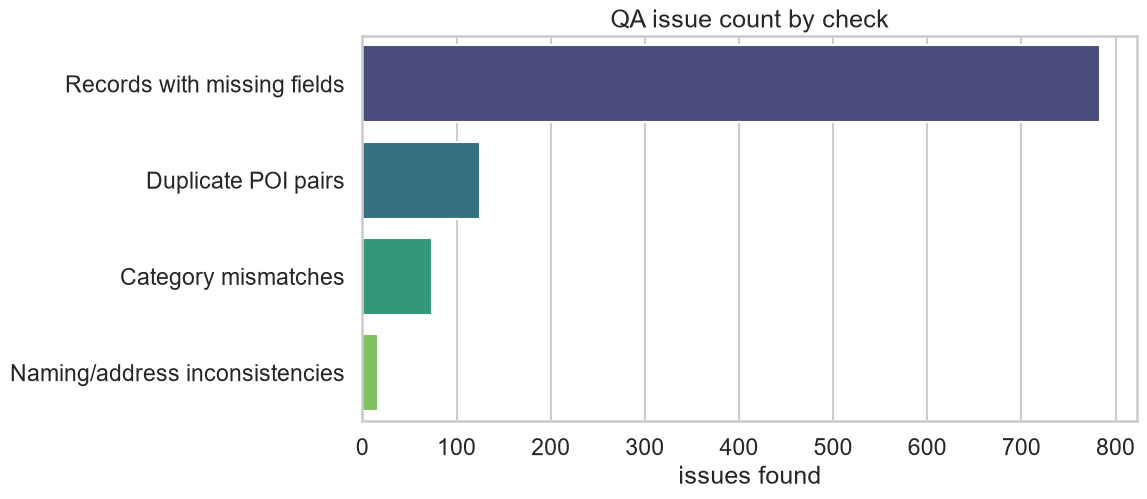

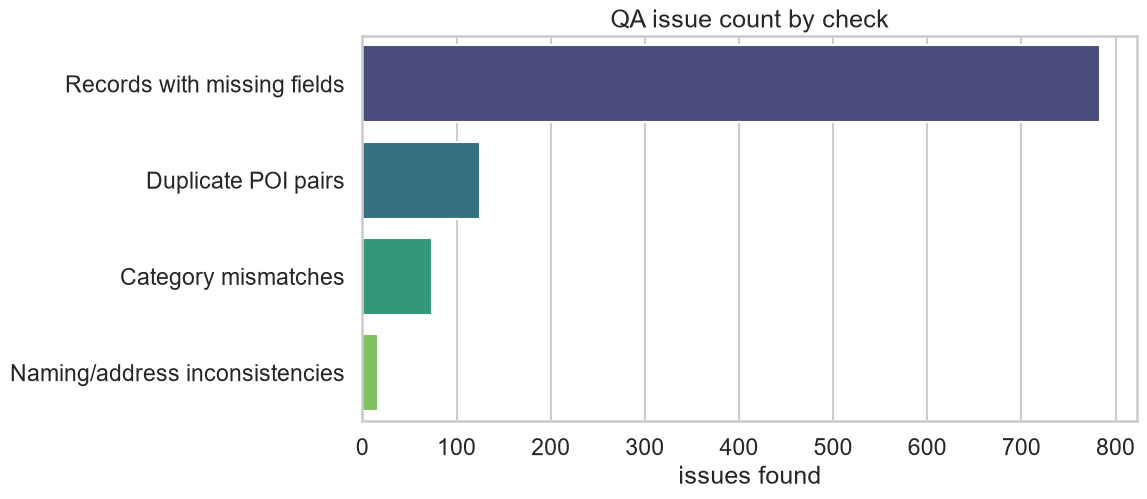

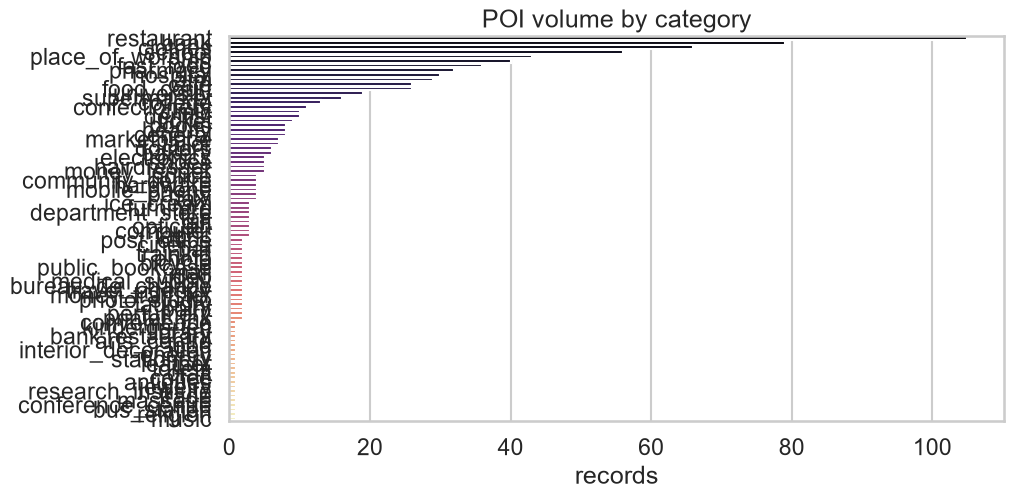

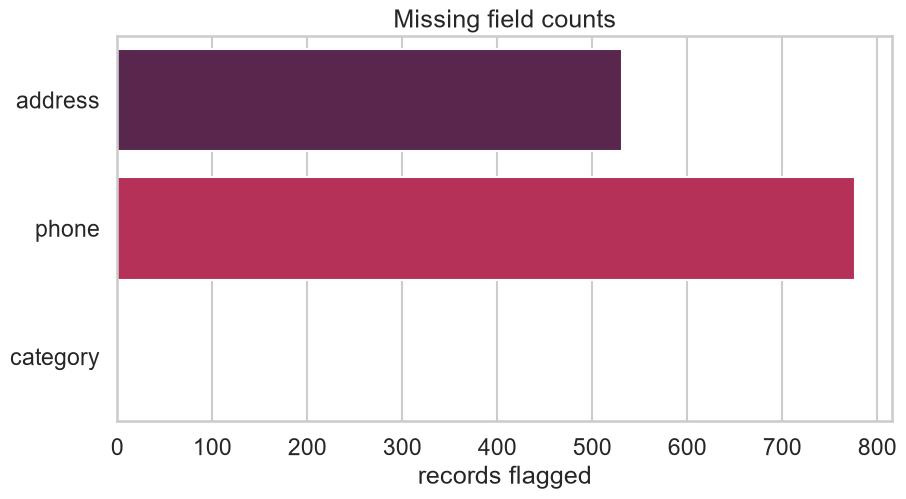

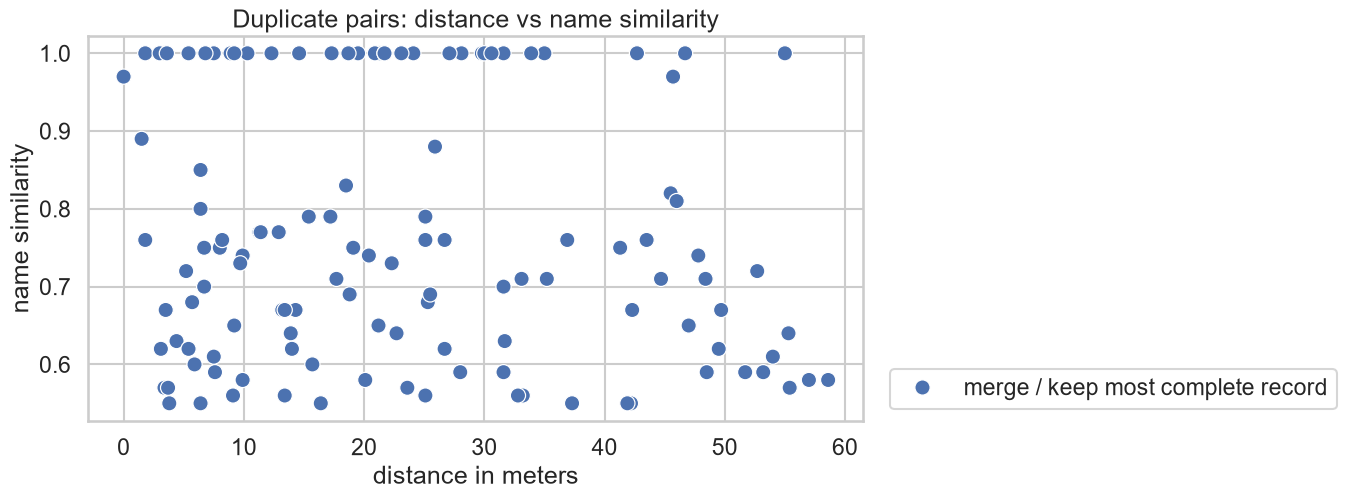

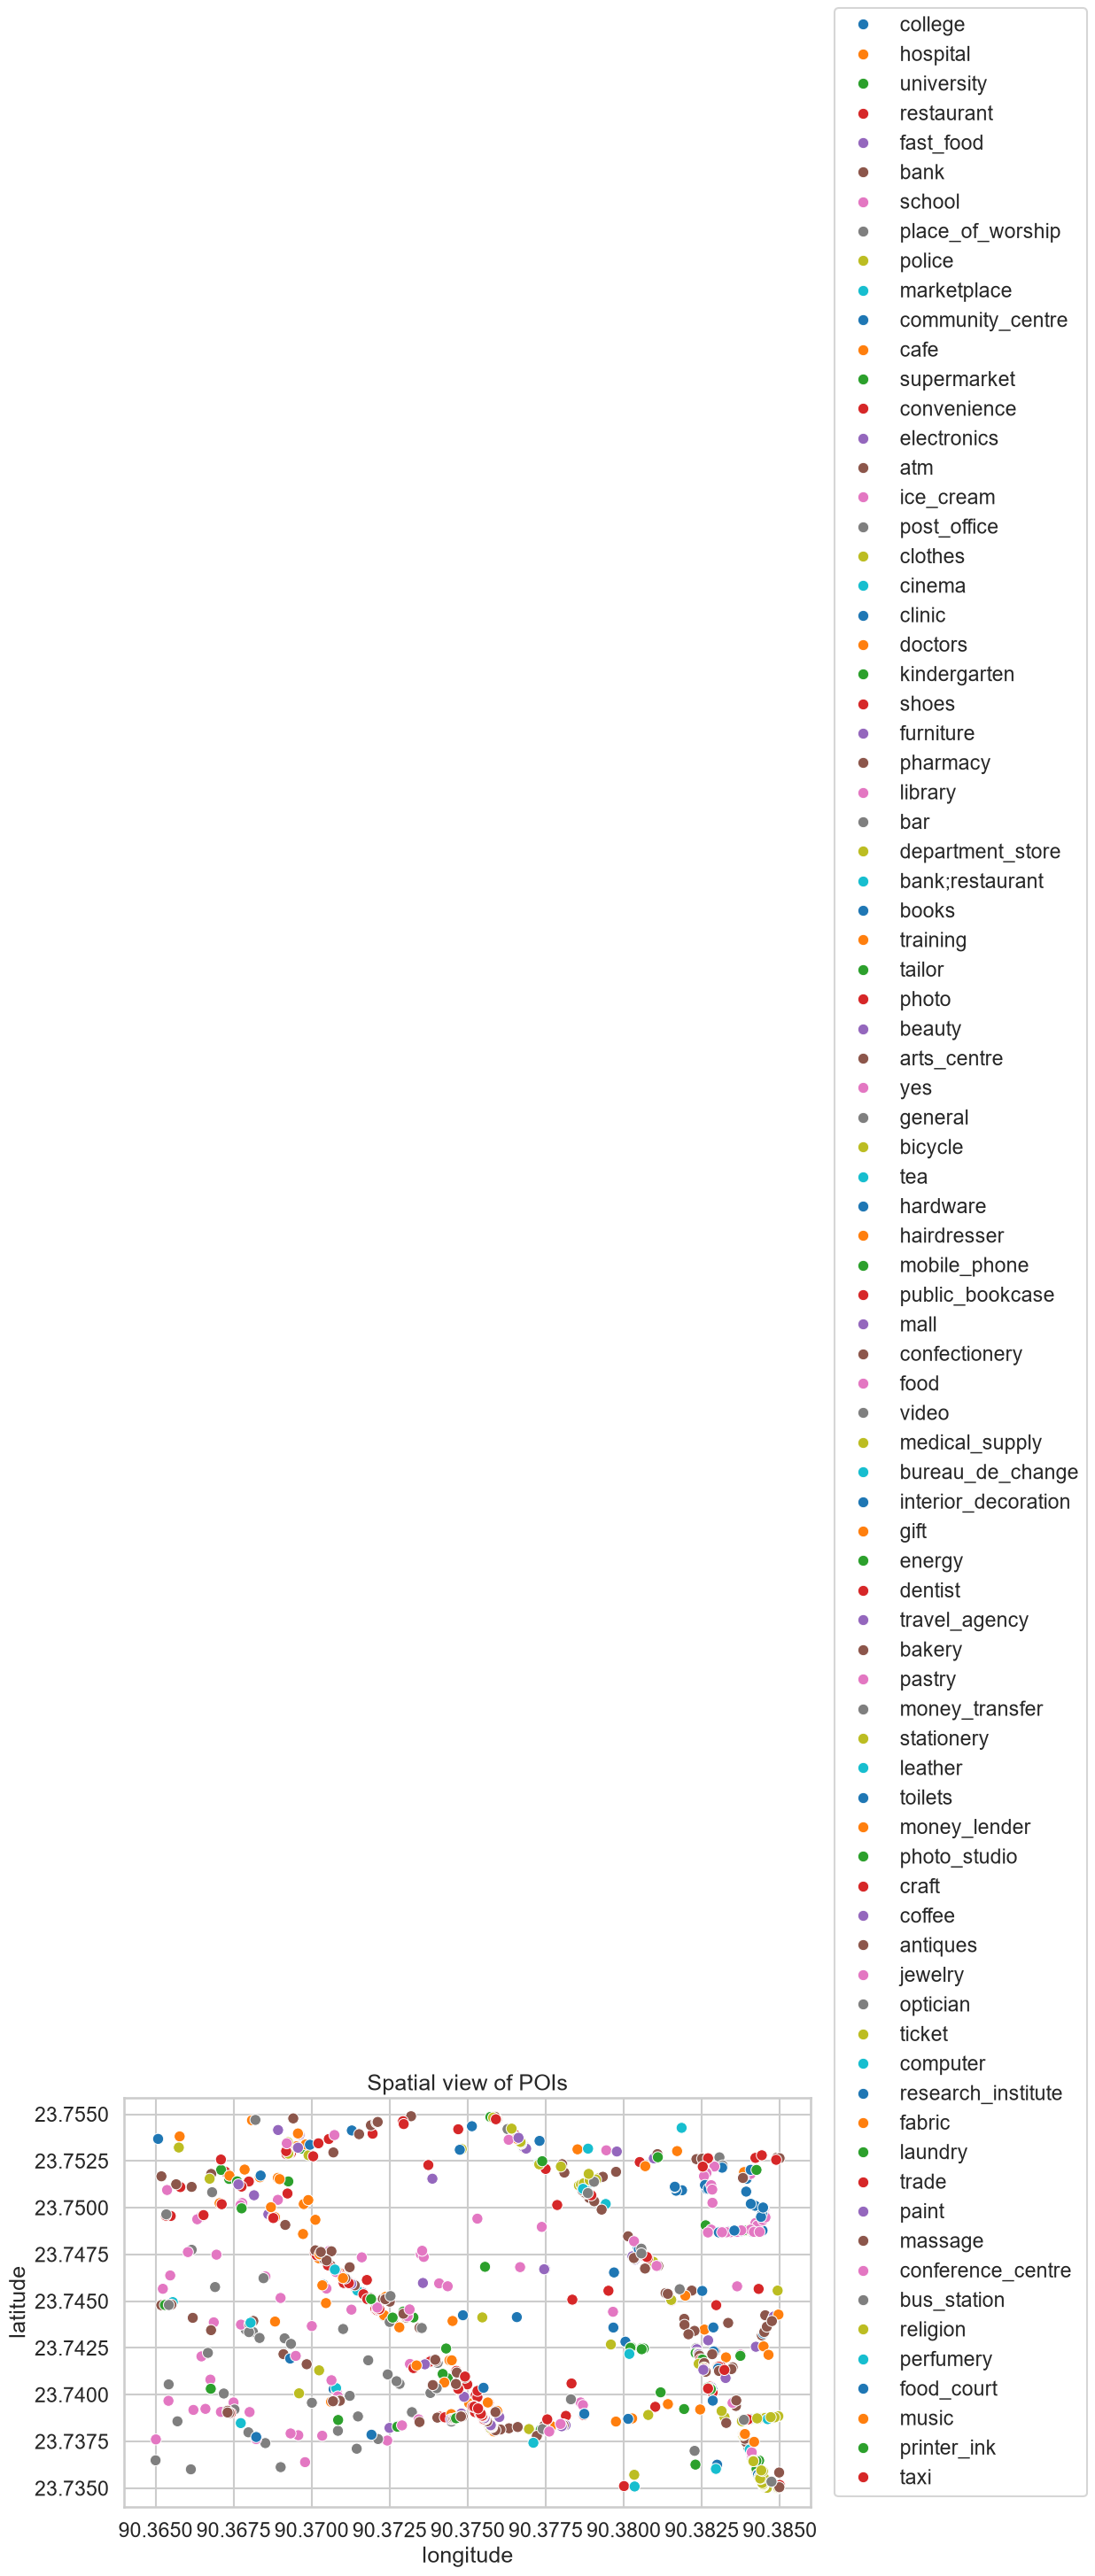

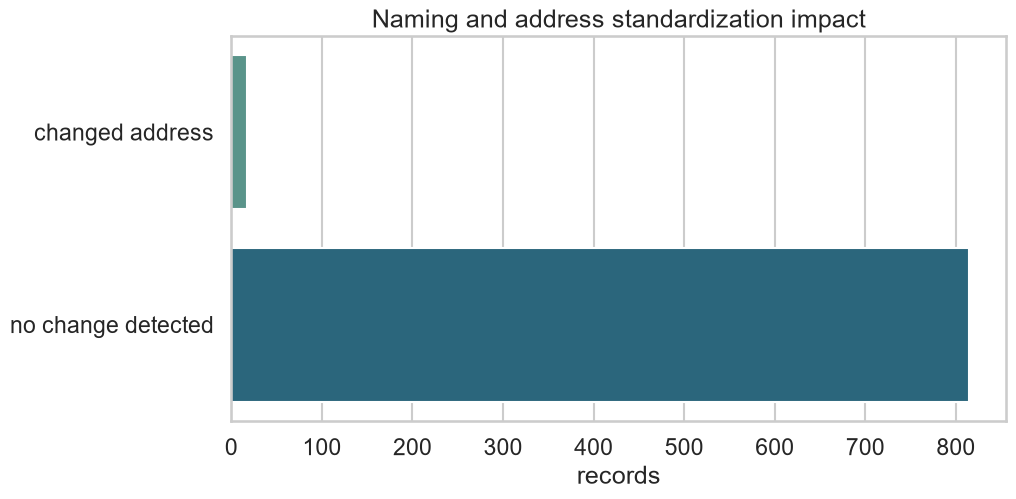

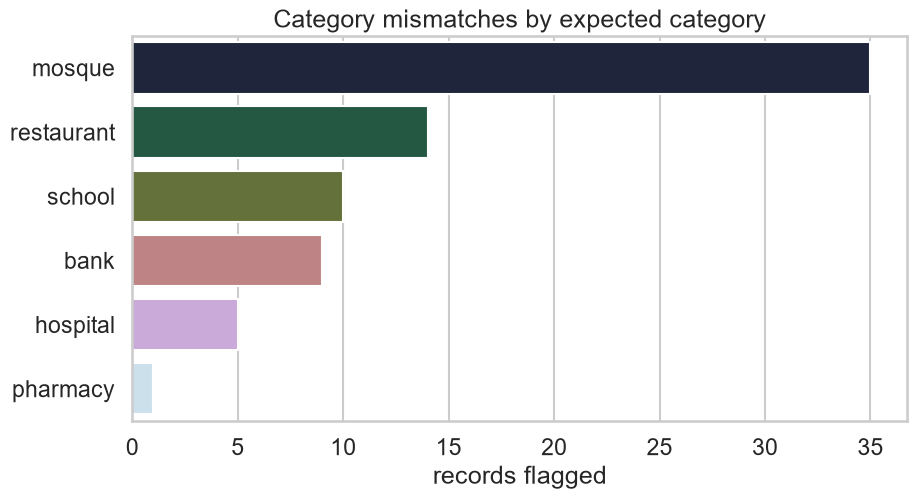

### POI volume by category

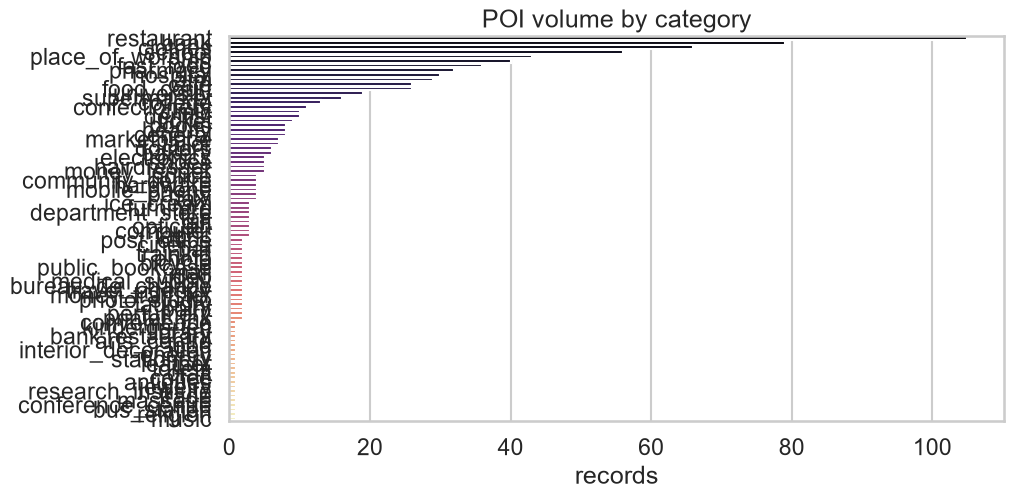

### Missing field counts

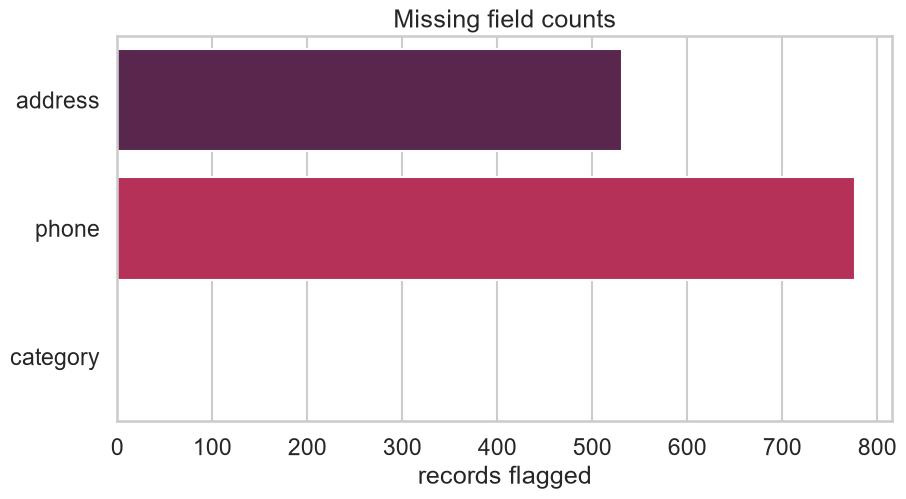

### Duplicate pairs: distance vs name similarity

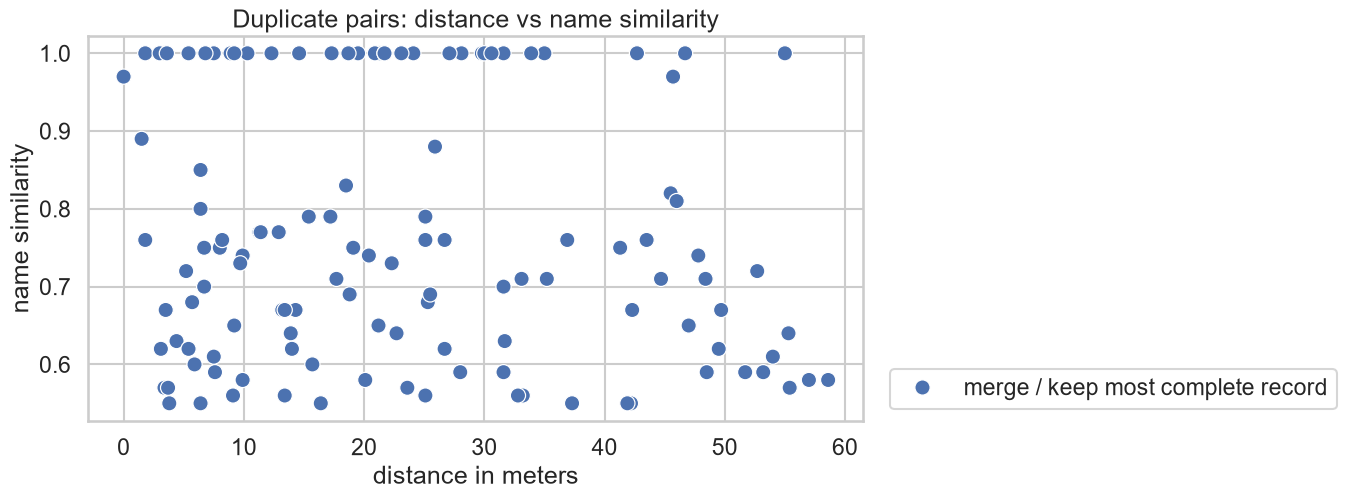

### Spatial view of POIs

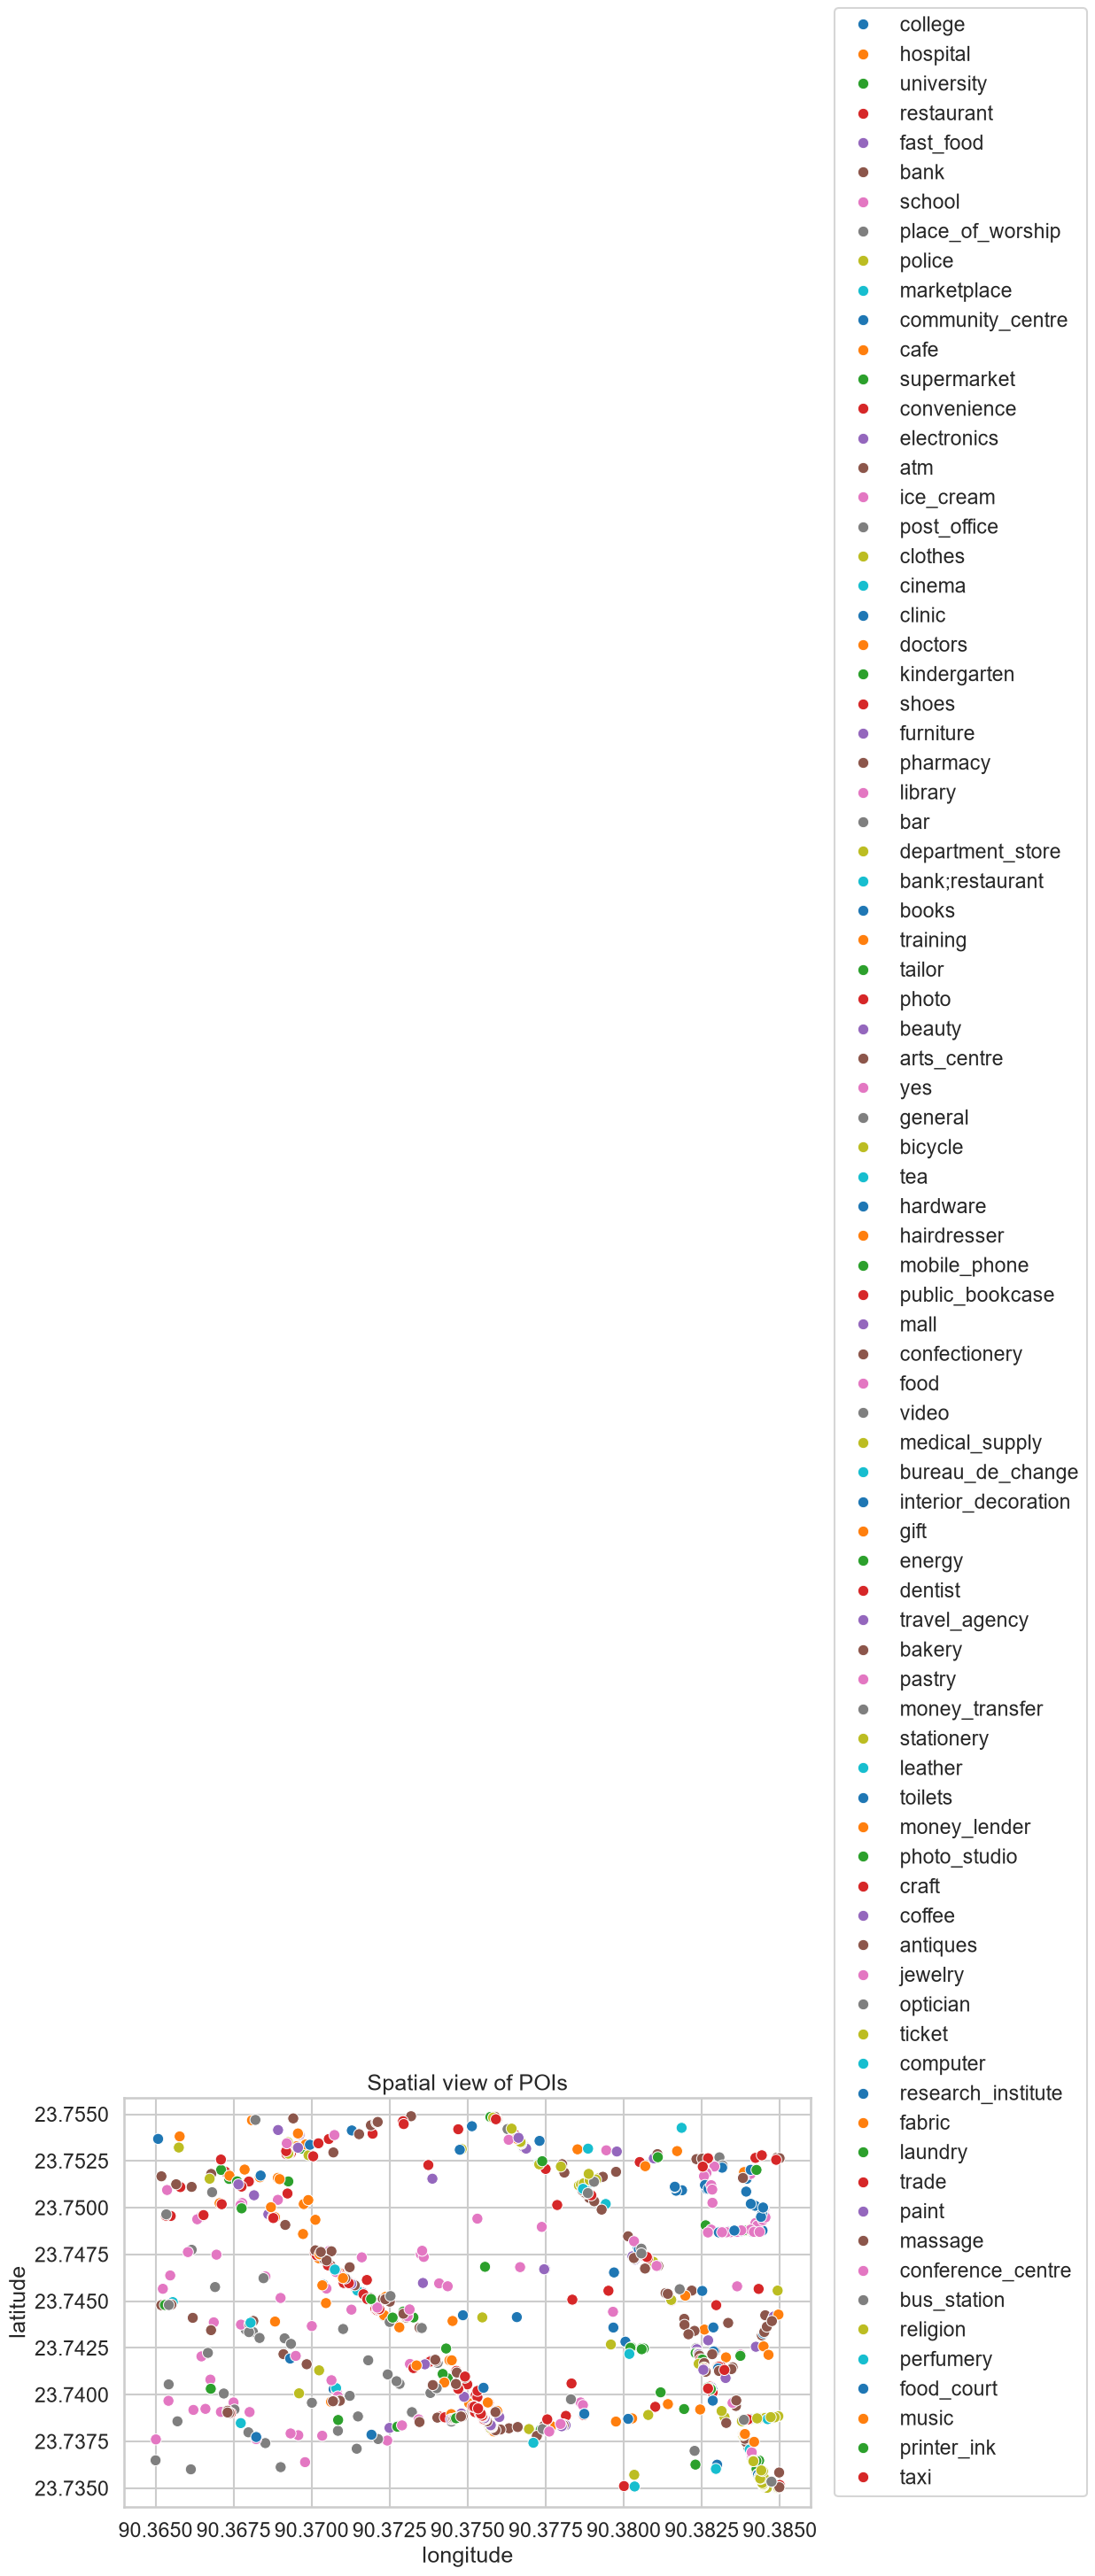

### Naming and address standardization impact

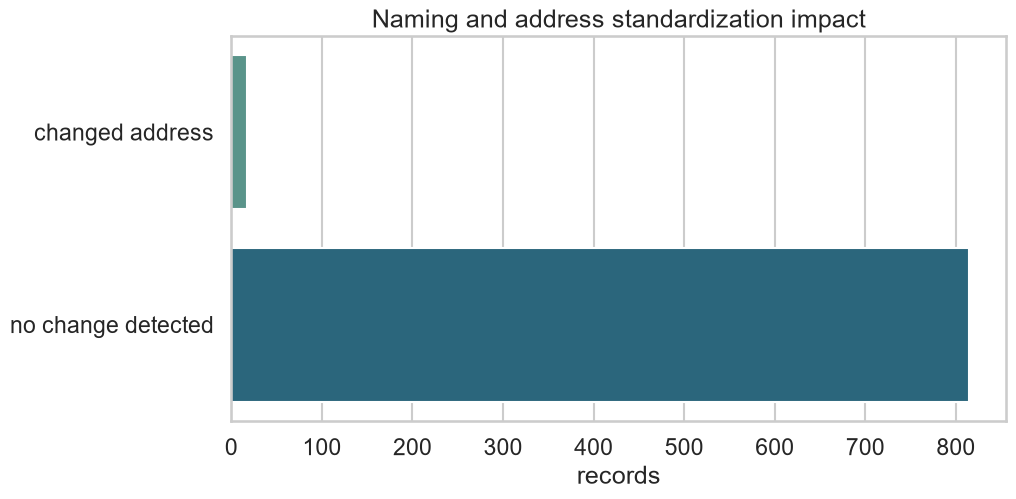

### Category mismatches by expected category

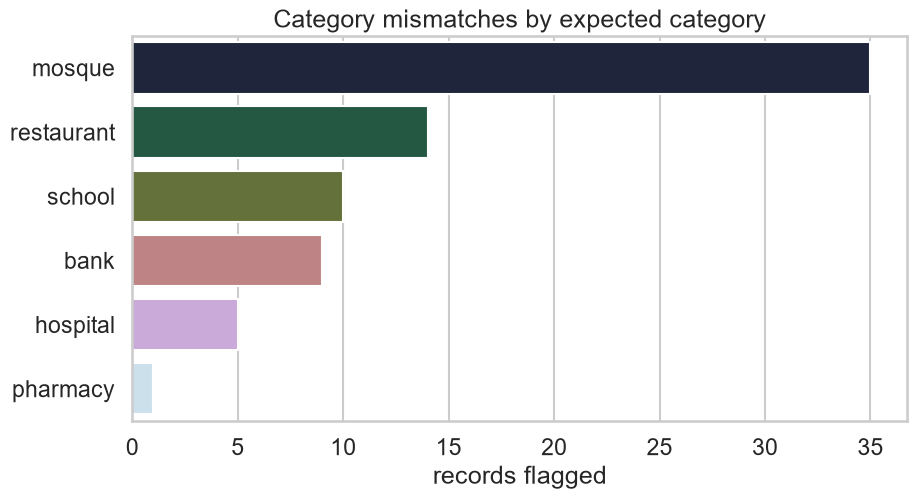

In [10]:
def plot_figures(results):
    input_df = results["input_df"].copy()
    summary_df = results["summary"].copy()
    duplicates_df = results["duplicates"].copy()
    missing_df = results["missing"].copy()
    naming_df = results["naming"].copy()
    category_df = results["category"].copy()

    figs = {}

    fig, ax = plt.subplots(figsize=(10, 5))
    summary_plot = summary_df.sort_values("issues_found", ascending=False)
    sns.barplot(data=summary_plot, x="issues_found", y="check", ax=ax, palette="viridis")
    ax.set_title("QA issue count by check")
    ax.set_xlabel("issues found")
    ax.set_ylabel("")
    figs["qa_summary"] = fig

    fig, ax = plt.subplots(figsize=(10, 5))
    category_counts = (
        input_df["category"].fillna("missing").astype(str).str.strip().replace("", "missing").value_counts().reset_index()
    )
    category_counts.columns = ["category", "count"]
    sns.barplot(data=category_counts, x="count", y="category", ax=ax, palette="magma")
    ax.set_title("POI volume by category")
    ax.set_xlabel("records")
    ax.set_ylabel("")
    figs["category_distribution"] = fig

    fig, ax = plt.subplots(figsize=(10, 5))
    missing_breakdown = pd.DataFrame(
        {
            "field": REQUIRED_FIELDS,
            "count": [missing_df["missing_fields"].str.contains(field, na=False).sum() for field in REQUIRED_FIELDS],
        }
    )
    sns.barplot(data=missing_breakdown, x="count", y="field", ax=ax, palette="rocket")
    ax.set_title("Missing field counts")
    ax.set_xlabel("records flagged")
    ax.set_ylabel("")
    figs["missing_fields"] = fig

    fig, ax = plt.subplots(figsize=(10, 5))
    if duplicates_df.empty:
        ax.text(0.5, 0.5, "No duplicate pairs detected", ha="center", va="center", fontsize=14)
        ax.set_axis_off()
    else:
        sns.scatterplot(
            data=duplicates_df,
            x="distance_meters",
            y="name_similarity",
            hue="suggested_action",
            s=120,
            ax=ax,
        )
        ax.set_title("Duplicate pairs: distance vs name similarity")
        ax.set_xlabel("distance in meters")
        ax.set_ylabel("name similarity")
        ax.legend(loc="lower left", bbox_to_anchor=(1.02, 0))
    figs["duplicates"] = fig

    fig, ax = plt.subplots(figsize=(10, 6))
    spatial_df = input_df.dropna(subset=["latitude", "longitude"]).copy()
    if spatial_df.empty:
        ax.text(0.5, 0.5, "No coordinate data available", ha="center", va="center", fontsize=14)
        ax.set_axis_off()
    else:
        spatial_df["category_clean"] = spatial_df["category"].fillna("missing").astype(str).replace("", "missing")
        sns.scatterplot(
            data=spatial_df,
            x="longitude",
            y="latitude",
            hue="category_clean",
            palette="tab10",
            s=80,
            ax=ax,
        )
        ax.set_title("Spatial view of POIs")
        ax.set_xlabel("longitude")
        ax.set_ylabel("latitude")
        ax.legend(loc="lower left", bbox_to_anchor=(1.02, 0))
    figs["spatial"] = fig

    fig, ax = plt.subplots(figsize=(10, 5))
    naming_summary = pd.DataFrame(
        {
            "status": ["changed address", "no change detected"],
            "count": [len(naming_df), max(len(input_df) - len(naming_df), 0)],
        }
    )
    sns.barplot(data=naming_summary, x="count", y="status", ax=ax, palette="crest")
    ax.set_title("Naming and address standardization impact")
    ax.set_xlabel("records")
    ax.set_ylabel("")
    figs["naming"] = fig

    fig, ax = plt.subplots(figsize=(10, 5))
    if category_df.empty:
        ax.text(0.5, 0.5, "No category mismatches detected", ha="center", va="center", fontsize=14)
        ax.set_axis_off()
    else:
        category_plot = category_df["expected_category"].value_counts().reset_index()
        category_plot.columns = ["expected_category", "count"]
        sns.barplot(data=category_plot, x="count", y="expected_category", ax=ax, palette="cubehelix")
        ax.set_title("Category mismatches by expected category")
        ax.set_xlabel("records flagged")
        ax.set_ylabel("")
    figs["category_mismatch"] = fig

    return figs


figures = plot_figures(results)

for title, key in [
    ("QA issue count by check", "qa_summary"),
    ("POI volume by category", "category_distribution"),
    ("Missing field counts", "missing_fields"),
    ("Duplicate pairs: distance vs name similarity", "duplicates"),
    ("Spatial view of POIs", "spatial"),
    ("Naming and address standardization impact", "naming"),
    ("Category mismatches by expected category", "category_mismatch"),
]:
    display(Markdown(f"### {title}"))
    display(figures[key])
    plt.show()
